# Notebook 06 — Model Comparison Visual Analysis

## Visualizing the 7-Architecture Benchmark

This notebook does not run any new experiments. It reads the results from `data/comparison/model_comparison.json` (produced by Notebook 05) and generates publication-quality visualizations for the thesis defense.

---

## Why a separate visualization notebook?

Notebook 05 trained and evaluated seven model architectures, producing a JSON file with the raw numbers. While the numerical results are sufficient for analysis, **visualizations communicate findings far more effectively** in a thesis defense setting.

This notebook addresses three needs:

1. **Communication.** A reviewer scanning the thesis can grasp the Pareto trade-offs from a single chart in seconds, whereas a table of numbers requires careful reading.

2. **Standalone artifacts.** Each chart is saved as a PNG that can be embedded directly into thesis chapters, defense slides, or presentations without re-running any code.

3. **Separation of concerns.** Notebook 05 is the experiment; this notebook is the report. Updating visualizations does not require re-training any models — just re-running this notebook.

---

## What this notebook produces

Seven visualizations, each accompanied by a markdown explanation of what the chart shows and how it should be read:

| Plot | Question Answered |
|---|---|
| Grafik 1: RMSE ranking | Which model has the lowest error? |
| Grafik 2: Accuracy vs inference speed | Which is the fastest accurate model? |
| Grafik 3: Accuracy vs parameter count | Which is the most parameter-efficient? |
| Grafik 4: Architecture family comparison | Sequential vs non-sequential models |
| Grafik 5: Multi-metric radar chart | All metrics at a glance |
| Grafik 6: Training vs inference time | Computational cost trade-off |
| Grafik 7: Normalized scores heatmap | Best per metric, color-coded |

All charts are saved to `data/comparison/plots/`.

---

## How to read this notebook

Each chart has three cells:

1. A markdown cell that **describes the chart before showing it** — what axes mean, which metric is on each side, what colors encode.
2. A code cell that **generates the chart** and saves it as PNG.
3. The chart output, which can be visually inspected.

Read the description first, then look at the chart with the description in mind.

---

## Source data

- File: `data/comparison/model_comparison.json`
- Source notebook: `notebooks/05_model_comparison.ipynb`
- Architectures: Linear Regression, Random Forest, XGBoost, 1D-CNN, GRU, LSTM, Transformer
- Dataset: C-MAPSS FD001 (14,459 training windows, 3,272 validation)
- Hardware: Hetzner CCX23 (16 GB RAM, CPU-only)

In [1]:
# Cell 1 — Setup and Load Results
# ===============================================================
# Read the model comparison JSON produced by Notebook 05 and prepare
# data structures for plotting.

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Paths
REPO_ROOT = Path("/root/thesis-infra")
COMPARISON_JSON = REPO_ROOT / "data" / "comparison" / "model_comparison.json"
PLOTS_DIR = REPO_ROOT / "data" / "comparison" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load
with open(COMPARISON_JSON) as f:
    data = json.load(f)

results = data["results"]
print(f"Loaded results for {len(results)} models:")
for key, r in results.items():
    print(f"  {r['model_name']:>20} | RMSE={r['rmse']:.2f}  params={r.get('param_count') or 'N/A'}")

# Color mapping by architecture family
# Sequential models (RNN/Transformer family) → blue tones
# Tree-based models → green tones
# Linear/CNN → gray/orange
MODEL_COLORS = {
    "Linear Regression": "#888780",   # gray
    "Random Forest":     "#1D9E75",   # teal
    "XGBoost":           "#0F6E56",   # darker teal
    "1D-CNN":            "#D85A30",   # coral
    "GRU":               "#185FA5",   # blue
    "LSTM":              "#534AB7",   # purple
    "Transformer":       "#7F77DD",   # light purple
}

# Architecture family classification
FAMILIES = {
    "Linear Regression": "Non-sequential",
    "Random Forest":     "Non-sequential",
    "XGBoost":           "Non-sequential",
    "1D-CNN":            "Local-temporal",
    "GRU":               "Sequential",
    "LSTM":              "Sequential",
    "Transformer":       "Sequential",
}

# Convenient lists for plotting (sorted by RMSE)
sorted_results = sorted(results.values(), key=lambda r: r["rmse"])
model_names = [r["model_name"] for r in sorted_results]
rmses = [r["rmse"] for r in sorted_results]
maes = [r["mae"] for r in sorted_results]
r2s = [r["r2"] for r in sorted_results]
train_times = [r["train_time_sec"] for r in sorted_results]
inference_times = [r["inference_ms_per_sample"] for r in sorted_results]
param_counts = [r.get("param_count") for r in sorted_results]
colors = [MODEL_COLORS[r["model_name"]] for r in sorted_results]
families = [FAMILIES[r["model_name"]] for r in sorted_results]

# Default plot style
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"\n✓ Setup complete. Plot output directory: {PLOTS_DIR}")


Loaded results for 7 models:
     Linear Regression | RMSE=17.89  params=481
         Random Forest | RMSE=17.43  params=N/A
               XGBoost | RMSE=15.37  params=N/A
                1D-CNN | RMSE=18.70  params=8849
                   GRU | RMSE=12.70  params=40769
                  LSTM | RMSE=13.22  params=54337
           Transformer | RMSE=13.10  params=70017

✓ Setup complete. Plot output directory: /root/thesis-infra/data/comparison/plots


## Grafik 1: RMSE Sıralaması (Düşük = İyi)

### What this chart shows

A horizontal bar chart of validation RMSE for each architecture, sorted from best (lowest RMSE) to worst.

### Axes

- **X-axis:** RMSE on the validation set, in cycles. Lower is better. The thesis target is "as low as possible" — every cycle of error represents a unit of remaining useful life prediction inaccuracy.
- **Y-axis:** Model architectures, sorted by RMSE.

### Colors

Each architecture family has its own color:

- **Blue/purple** — Sequential models (GRU, LSTM, Transformer)
- **Teal** — Tree-based ensembles (RF, XGBoost)
- **Gray** — Linear baseline
- **Coral** — Convolutional (1D-CNN)

### What to look for

- The gap between the best sequential model and the best non-sequential model indicates how much temporal modeling helps.
- A horizontal "threshold line" at the LSTM (selected production model) shows where alternatives stand relative to the deployed choice.

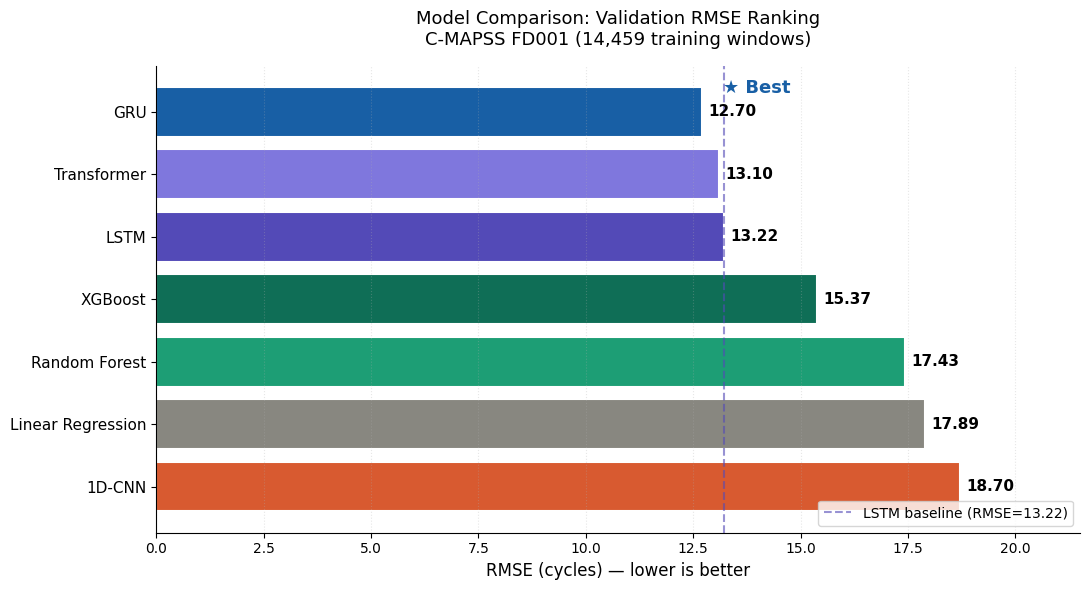

✓ Saved: 01_rmse_ranking.png


In [2]:
# Cell 3 — Plot 1: RMSE Ranking
# ===============================================================

fig, ax = plt.subplots(figsize=(11, 6))

# Horizontal bar plot
y_pos = np.arange(len(model_names))
bars = ax.barh(y_pos, rmses, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels at end of each bar
for i, (bar, val) in enumerate(zip(bars, rmses)):
    ax.text(val + 0.15, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', fontsize=11, fontweight='bold')

# Highlight LSTM with a vertical reference line
lstm_rmse = results["lstm"]["rmse"]
ax.axvline(lstm_rmse, color='#534AB7', linestyle='--', linewidth=1.5, alpha=0.6,
           label=f'LSTM baseline (RMSE={lstm_rmse:.2f})')

# Mark the best model
best_idx = 0  # already sorted
ax.text(rmses[0] + 0.5, y_pos[0] - 0.3, '★ Best', fontsize=13, color='#185FA5',
        fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(model_names, fontsize=11)
ax.invert_yaxis()  # Best at top
ax.set_xlabel('RMSE (cycles) — lower is better', fontsize=12)
ax.set_title('Model Comparison: Validation RMSE Ranking\nC-MAPSS FD001 (14,459 training windows)',
             fontsize=13, pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3, linestyle=':')
ax.set_xlim(0, max(rmses) * 1.15)

plt.tight_layout()
plot_path = PLOTS_DIR / "01_rmse_ranking.png"
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {plot_path.name}")


## Grafik 2: Accuracy vs Inference Speed (Pareto Front)

### What this chart shows

A scatter plot where each model is a single point. The **Pareto front** — the set of models that are not dominated by any other — is highlighted with a connected line.

### Axes

- **X-axis:** Inference time per sample (milliseconds, log scale). Lower is better.
- **Y-axis:** Validation RMSE (cycles). Lower is better.

### What is a Pareto front?

A model is "Pareto-optimal" if no other model is **both more accurate and faster**. These models form the boundary of achievable trade-offs:

- Models **on** the Pareto front represent meaningful choices — each one is the best at some accuracy/speed balance.
- Models **above and to the right** of the front are "dominated" — there is always a better choice.

### What to look for

- Which models lie on the Pareto front? These are the candidates for production deployment.
- How far is LSTM (the selected production model) from the front? If it's on the front, the choice is justified. If it's not, an alternative is strictly better.

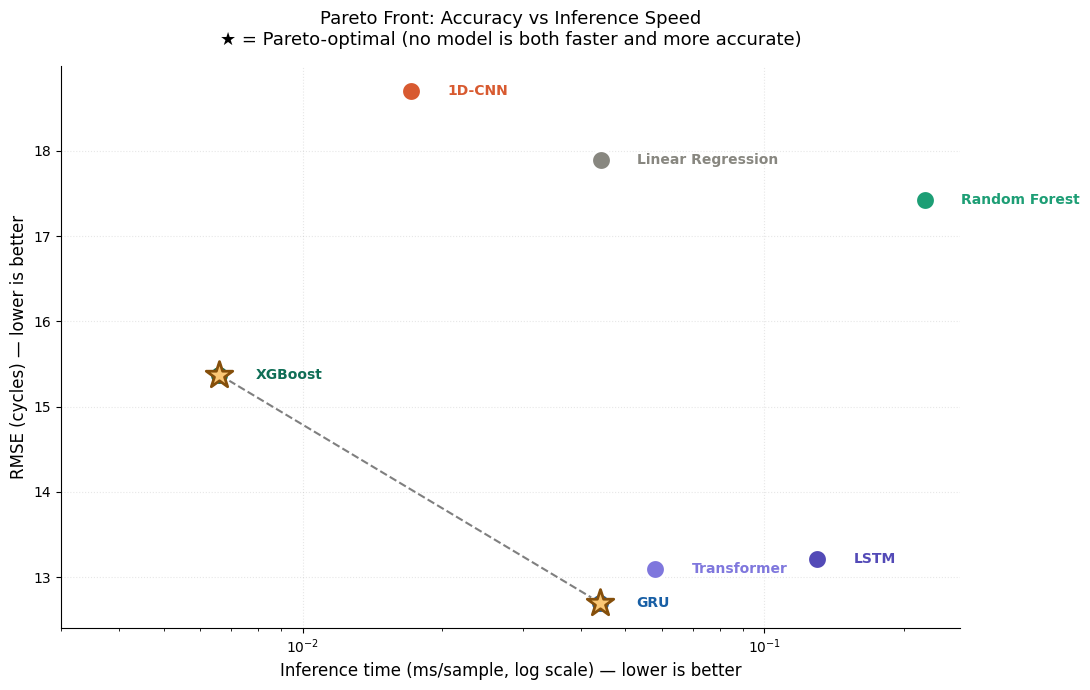

✓ Saved: 02_pareto_accuracy_vs_speed.png

Pareto-optimal models (★):
  XGBoost: RMSE=15.37, inference=0.0066 ms
  GRU: RMSE=12.70, inference=0.0440 ms


In [3]:
# Cell 5 — Plot 2: Pareto Front (Accuracy vs Inference Speed)
# ===============================================================

fig, ax = plt.subplots(figsize=(11, 7))

# Scatter all models
for r in results.values():
    name = r["model_name"]
    ax.scatter(r["inference_ms_per_sample"], r["rmse"],
               s=200, color=MODEL_COLORS[name], edgecolor='white',
               linewidth=2, zorder=3, label=name)
    # Label each point
    offset_x = r["inference_ms_per_sample"] * 1.2
    ax.annotate(name, xy=(r["inference_ms_per_sample"], r["rmse"]),
                xytext=(offset_x, r["rmse"]),
                fontsize=10, va='center',
                color=MODEL_COLORS[name], fontweight='bold')

# Compute Pareto front (lower-left frontier)
points = [(r["inference_ms_per_sample"], r["rmse"], r["model_name"])
          for r in results.values()]
points.sort()  # sort by inference time ascending
pareto = []
best_rmse_so_far = float('inf')
for x, y, name in points:
    if y < best_rmse_so_far:
        pareto.append((x, y, name))
        best_rmse_so_far = y

# Draw Pareto front line
pareto_x = [p[0] for p in pareto]
pareto_y = [p[1] for p in pareto]
ax.plot(pareto_x, pareto_y, 'k--', alpha=0.5, linewidth=1.5,
        label='Pareto front', zorder=2)

# Mark Pareto-optimal models with a star
for x, y, name in pareto:
    ax.scatter(x, y, s=400, marker='*', color='#FAC775',
               edgecolor='#854F0B', linewidth=2, zorder=4)

ax.set_xscale('log')
ax.set_xlabel('Inference time (ms/sample, log scale) — lower is better', fontsize=12)
ax.set_ylabel('RMSE (cycles) — lower is better', fontsize=12)
ax.set_title('Pareto Front: Accuracy vs Inference Speed\n★ = Pareto-optimal (no model is both faster and more accurate)',
             fontsize=13, pad=15)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(left=0.003)

plt.tight_layout()
plot_path = PLOTS_DIR / "02_pareto_accuracy_vs_speed.png"
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {plot_path.name}")
print(f"\nPareto-optimal models (★):")
for x, y, name in pareto:
    print(f"  {name}: RMSE={y:.2f}, inference={x:.4f} ms")


## Grafik 3: Accuracy vs Parameter Count

### What this chart shows

For neural network models, the relationship between **model size** (number of trainable parameters) and **accuracy** (RMSE). Tree-based models are excluded because they don't have a well-defined parameter count.

### Axes

- **X-axis:** Number of trainable parameters (log scale).
- **Y-axis:** Validation RMSE.

### Why this matters

For production deployment on resource-constrained hardware (e.g., the Hetzner CCX23 VM, edge devices), smaller models are preferable. The key question:

> "Does adding parameters actually improve accuracy?"

If the curve is flat above some parameter count, additional parameters are wasted. If the curve is steep, more parameters help.

### What to look for

- Which neural network achieves the best accuracy per parameter?
- Is there a "sweet spot" — a model that achieves near-best accuracy with minimal parameters?
- How does CNN (smallest, ~9K params) compare to recurrent models (~40K-70K params)?

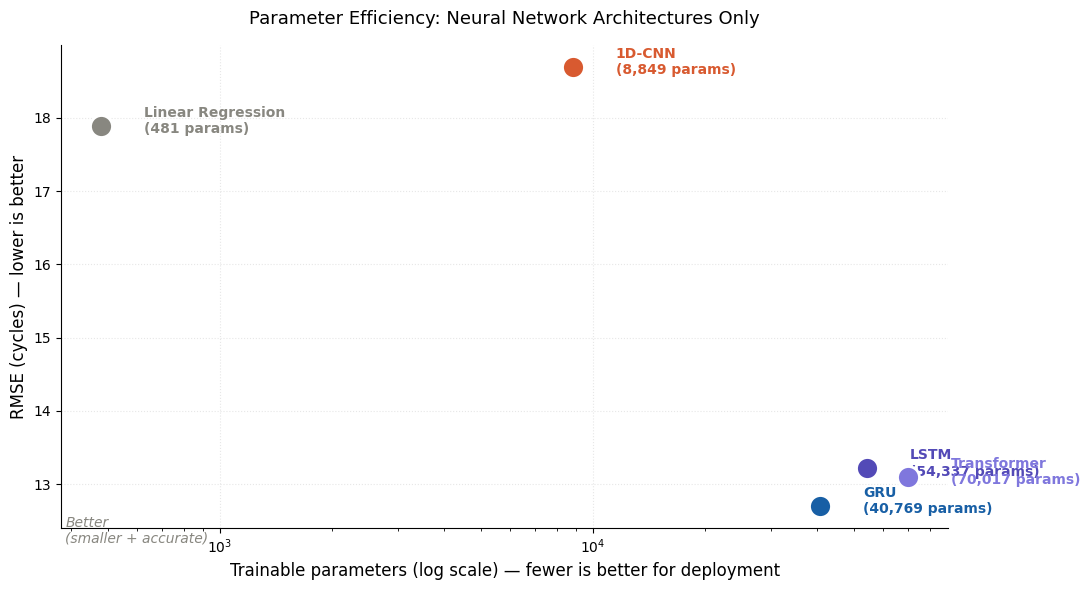

✓ Saved: 03_accuracy_vs_params.png


In [4]:
# Cell 7 — Plot 3: Accuracy vs Parameter Count
# ===============================================================

# Only neural models have well-defined parameter counts
nn_models = [r for r in results.values() if r.get("param_count")]

fig, ax = plt.subplots(figsize=(11, 6))

for r in nn_models:
    name = r["model_name"]
    ax.scatter(r["param_count"], r["rmse"],
               s=250, color=MODEL_COLORS[name], edgecolor='white',
               linewidth=2, zorder=3)
    # Annotate
    ax.annotate(f'{name}\n({r["param_count"]:,} params)',
                xy=(r["param_count"], r["rmse"]),
                xytext=(r["param_count"] * 1.3, r["rmse"] - 0.1),
                fontsize=10, color=MODEL_COLORS[name], fontweight='bold')

# Draw "ideal" lower-left direction arrow
ax.annotate('', xy=(min(r["param_count"] for r in nn_models) * 0.7,
                    min(r["rmse"] for r in nn_models) * 0.95),
            xytext=(max(r["param_count"] for r in nn_models) * 1.2,
                    max(r["rmse"] for r in nn_models) * 1.05),
            arrowprops=dict(arrowstyle='->', color='#888780', lw=1.5, alpha=0.4))
ax.text(min(r["param_count"] for r in nn_models) * 0.8,
        min(r["rmse"] for r in nn_models) - 0.5,
        'Better\n(smaller + accurate)', fontsize=10, color='#888780', fontstyle='italic')

ax.set_xscale('log')
ax.set_xlabel('Trainable parameters (log scale) — fewer is better for deployment',
              fontsize=12)
ax.set_ylabel('RMSE (cycles) — lower is better', fontsize=12)
ax.set_title('Parameter Efficiency: Neural Network Architectures Only',
             fontsize=13, pad=15)
ax.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plot_path = PLOTS_DIR / "03_accuracy_vs_params.png"
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {plot_path.name}")


## Grafik 4: Mimari Aile Karşılaştırması

### What this chart shows

A grouped comparison showing how **architecture families** perform on average, with individual models as data points. Three families:

1. **Sequential** (GRU, LSTM, Transformer): explicitly model temporal dependencies across the full input sequence.
2. **Local-temporal** (1D-CNN): captures local patterns through convolutions, but no long-range dependency modeling.
3. **Non-sequential** (Linear, Random Forest, XGBoost): treat each input window as a flat feature vector, ignoring temporal order.

### Why this matters

This is the **key thesis argument**: long-range temporal dependencies are essential for RUL prediction. The chart visualizes this claim quantitatively.

### What to look for

- The mean RMSE per family — does the sequential family clearly outperform the others?
- The spread within each family — is there overlap between families, or are they cleanly separated?
- The gap between sequential and non-sequential families — this is the **value of temporal modeling**.

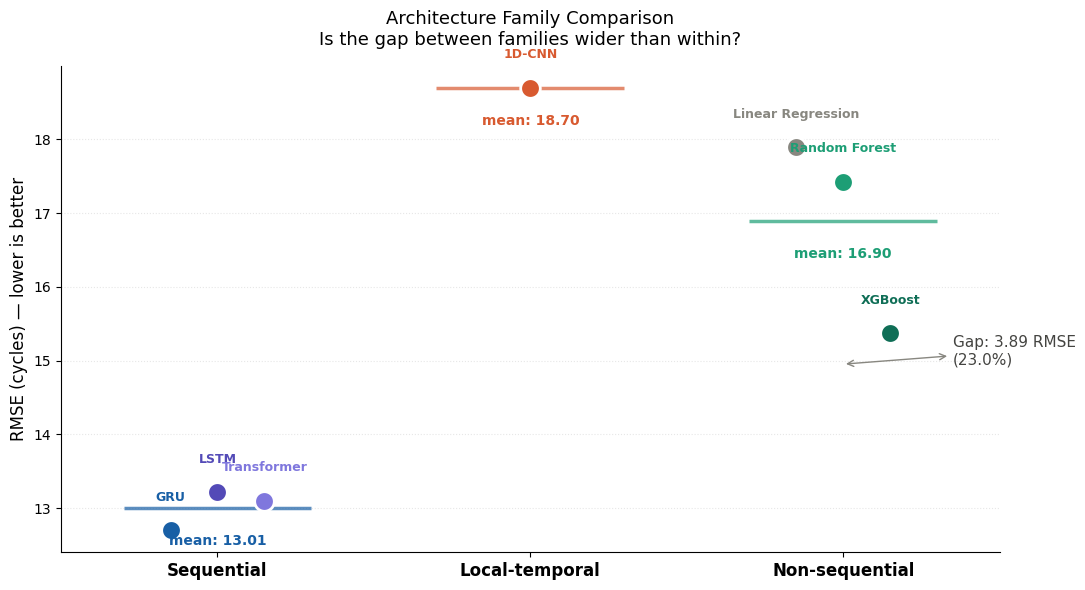

✓ Saved: 04_family_comparison.png

Family means:
       Sequential: mean RMSE = 13.01 (n=3)
   Local-temporal: mean RMSE = 18.70 (n=1)
   Non-sequential: mean RMSE = 16.90 (n=3)


In [5]:
# Cell 9 — Plot 4: Architecture Family Comparison
# ===============================================================

# Group models by family
family_data = {"Sequential": [], "Local-temporal": [], "Non-sequential": []}
for r in results.values():
    fam = FAMILIES[r["model_name"]]
    family_data[fam].append((r["model_name"], r["rmse"]))

family_order = ["Sequential", "Local-temporal", "Non-sequential"]
family_colors = {"Sequential": "#185FA5", "Local-temporal": "#D85A30",
                 "Non-sequential": "#1D9E75"}

fig, ax = plt.subplots(figsize=(11, 6))

x_positions = []
for i, fam in enumerate(family_order):
    family_models = family_data[fam]
    family_rmses = [r for _, r in family_models]
    family_mean = np.mean(family_rmses)
    
    # Draw "family band" — mean as horizontal line
    x_center = i + 0.5
    
    # Individual points
    for j, (name, rmse) in enumerate(family_models):
        x_jitter = x_center + (j - (len(family_models)-1)/2) * 0.15
        x_positions.append((x_jitter, rmse, name))
        ax.scatter(x_jitter, rmse, s=200, color=MODEL_COLORS[name],
                   edgecolor='white', linewidth=2, zorder=3)
        ax.annotate(name, xy=(x_jitter, rmse), xytext=(x_jitter, rmse + 0.4),
                    fontsize=9, ha='center', color=MODEL_COLORS[name],
                    fontweight='bold')
    
    # Family mean line
    ax.hlines(family_mean, x_center - 0.3, x_center + 0.3,
              color=family_colors[fam], linewidth=2.5, alpha=0.7)
    ax.text(x_center, family_mean - 0.5, f'mean: {family_mean:.2f}',
            ha='center', fontsize=10, color=family_colors[fam], fontweight='bold')

ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(family_order, fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (cycles) — lower is better', fontsize=12)
ax.set_title('Architecture Family Comparison\nIs the gap between families wider than within?',
             fontsize=13, pad=15)
ax.set_xlim(0, 3)
ax.grid(axis='y', alpha=0.3, linestyle=':')

# Annotate the gap
seq_mean = np.mean([r for _, r in family_data["Sequential"]])
non_mean = np.mean([r for _, r in family_data["Non-sequential"]])
gap = non_mean - seq_mean
ax.annotate(f'Gap: {gap:.2f} RMSE\n({100*gap/non_mean:.1f}%)',
            xy=(2.5, (seq_mean + non_mean) / 2),
            xytext=(2.85, (seq_mean + non_mean) / 2),
            fontsize=11, color='#444441', ha='left',
            arrowprops=dict(arrowstyle='<->', color='#888780', lw=1))

plt.tight_layout()
plot_path = PLOTS_DIR / "04_family_comparison.png"
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {plot_path.name}")
print(f"\nFamily means:")
for fam in family_order:
    rmses_f = [r for _, r in family_data[fam]]
    print(f"  {fam:>15}: mean RMSE = {np.mean(rmses_f):.2f} (n={len(rmses_f)})")


## Grafik 5: Multi-Metric Radar Chart

### What this chart shows

For each architecture, a radar chart showing **all five metrics at once** — normalized to [0, 1] where 1 is best, 0 is worst:

- **Accuracy:** Higher = lower RMSE
- **Inference Speed:** Higher = faster inference per sample
- **Train Speed:** Higher = faster training
- **Parameter Efficiency:** Higher = fewer parameters per RMSE point
- **R² Score:** Higher = better variance explanation

### How to read this

- A **larger area** means better overall performance.
- A **balanced shape** (regular pentagon) means the model is consistently good at everything.
- A **lopsided shape** means the model excels at some axes but fails at others.

### What to look for

- Which model has the largest area? (best overall)
- Which model has the most balanced shape?
- Which axes does LSTM dominate? Which does GRU dominate?

### Limitations

This chart is comparison-relative — normalization is per-axis across the seven models, so adding/removing a model changes the chart for everyone. It is not a substitute for absolute metric comparisons.

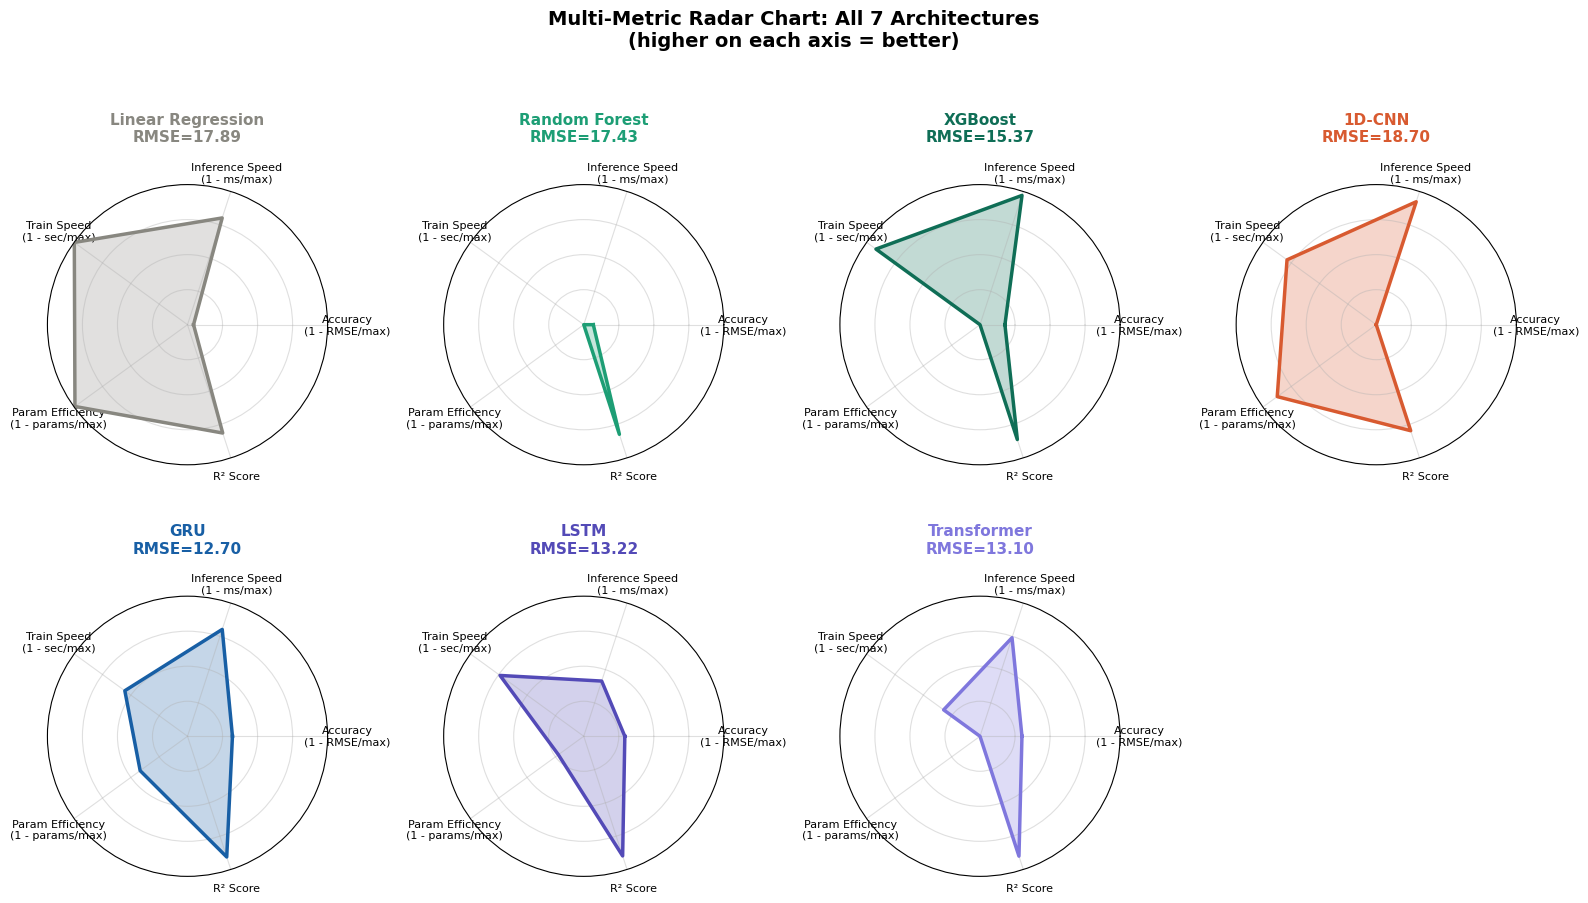

✓ Saved: 05_radar_chart.png


In [6]:
# Cell 11 — Plot 5: Radar Chart
# ===============================================================

# Five axes (metrics, normalized so higher = better)
metric_keys = ["accuracy", "inference_speed", "train_speed", "param_efficiency", "r2"]
metric_labels = ["Accuracy\n(1 - RMSE/max)", "Inference Speed\n(1 - ms/max)",
                 "Train Speed\n(1 - sec/max)", "Param Efficiency\n(1 - params/max)",
                 "R² Score"]

# Compute normalized scores per model
max_rmse = max(rmses)
max_inf = max(inference_times)
max_train = max(train_times)
max_params = max(p for p in param_counts if p is not None)

normalized = {}
for r in results.values():
    name = r["model_name"]
    pc = r.get("param_count") or max_params  # if N/A, treat as max
    normalized[name] = {
        "accuracy": 1 - r["rmse"] / max_rmse,
        "inference_speed": 1 - r["inference_ms_per_sample"] / max_inf,
        "train_speed": 1 - r["train_time_sec"] / max_train,
        "param_efficiency": 1 - pc / max_params,
        "r2": r["r2"],
    }

# Set up radar chart
angles = np.linspace(0, 2 * np.pi, len(metric_keys), endpoint=False).tolist()
angles += [angles[0]]  # close the polygon

fig, axes = plt.subplots(2, 4, figsize=(16, 9), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Plot each model in its own subplot
for idx, name in enumerate(MODEL_COLORS.keys()):
    if name not in normalized:
        continue
    ax = axes[idx]
    values = [normalized[name][k] for k in metric_keys]
    values += [values[0]]  # close
    
    ax.fill(angles, values, color=MODEL_COLORS[name], alpha=0.25)
    ax.plot(angles, values, color=MODEL_COLORS[name], linewidth=2.5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, fontsize=8)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['', '', ''], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'{name}\nRMSE={results[[k for k,r in results.items() if r["model_name"]==name][0]]["rmse"]:.2f}',
                 fontsize=11, fontweight='bold', color=MODEL_COLORS[name], pad=15)
    ax.grid(True, alpha=0.4)

# Hide unused subplot
axes[-1].axis('off')

fig.suptitle('Multi-Metric Radar Chart: All 7 Architectures\n(higher on each axis = better)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plot_path = PLOTS_DIR / "05_radar_chart.png"
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {plot_path.name}")
